In [9]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from math import dist

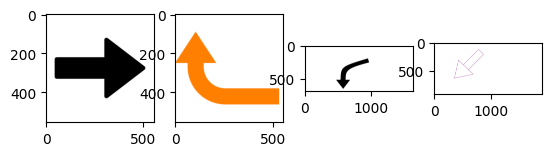

In [10]:
# images
img1 = cv.imread(r"data\arrow1.png")
img2 = cv.imread(r"data\arrow2.png")
img3 = cv.imread(r"data\arrow3.png")
img4 = cv.imread(r"data\arrow4.png")



plt.subplot(141);plt.imshow(img1[...,::-1])
plt.subplot(142);plt.imshow(img2[...,::-1])
plt.subplot(143);plt.imshow(img3[...,::-1])
plt.subplot(144);plt.imshow(img4[...,::-1])


In [17]:


def operation(img):
    cimg = img.copy()

    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    gray = cv.GaussianBlur(gray, (3,3), 1)
    edges = cv.Canny(gray, 50, 255)
    contours, _ = cv.findContours(edges, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

    sorted_contours = sorted(contours, key=cv.contourArea, reverse=True)[:4]

    corners_list = []
    corners = cv.goodFeaturesToTrack(gray, 7, 0.0001, 50)
    for c in corners:
        x, y = c[0]
        x, y = int(x), int(y)   
        corners_list.append([x,y])



    for c in sorted_contours:
        M = cv.moments(c)
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])



    
    copy_corners_list = corners_list.copy()
    max_distances3 = []
    farthest_corners3 = []

    max_corner = []
    max_distance = 0
    for loop in range(3):
        for i in copy_corners_list:
            distance = dist([cx, cy], i)
            if distance > max_distance:
                max_corner = i
                max_distance = distance
        copy_corners_list.remove(max_corner)
        max_distances3.append(max_distance)
        farthest_corners3.append(max_corner)
        max_corner = []
        max_distance = 0


    min_corners = []
    closest_distance = 0
    for i in farthest_corners3:
        for j in farthest_corners3:
            distance = int(dist(i, j))
            if distance == 0:
                continue

            if closest_distance == 0:
                closest_distance = distance

            if distance <= closest_distance:
                closest_distance = distance
                min_corners = [i, j]

    farthest_corners3.remove(min_corners[0])
    farthest_corners3.remove(min_corners[1])

            

    dx = farthest_corners3[0][0] - cx
    dy = farthest_corners3[0][1] - cy
    angle = int(np.degrees(np.arctan2(-dy, dx)))
    cv.putText(cimg, str(angle)+": ", (10,30), cv.FONT_HERSHEY_COMPLEX, 1, (0,0,255), 1)

    if -45 <= angle <= 45:
        direction = "RIGHT"

    elif 45 < angle <= 135:
        direction = "UP"

    elif angle > 135 or angle < -135:
        direction = "LEFT"

    else:
        direction = "DOWN"

    cv.putText(cimg, str(direction), (120,30), cv.FONT_HERSHEY_COMPLEX, 1, (0,0,255), 1)


    return(cimg)

    


In [18]:
cv.imshow("1", operation(img1))
cv.imshow("2", operation(img2))
cv.imshow("3", operation(img3))
cv.imshow("4", operation(img4))

cv.waitKey(0)
cv.destroyAllWindows()

In [19]:
cv.imwrite(r"output\result1.png", operation(img1))
cv.imwrite(r"output\result2.png", operation(img2))
cv.imwrite(r"output\result3.png", operation(img3))
cv.imwrite(r"output\result4.png", operation(img4))

True